# FD001 Baseline Machine Learning for Remaining Useful Life (RUL) Prediction

This notebook builds on the prepared FD001 dataset from `01_data_preparation_eda_degradation_analysis.ipynb`. It trains and compares baseline machine learning regressors — Linear Regression, Random Forest, and Gradient Boosting — for predicting Remaining Useful Life (RUL) from engine operating settings and sensor measurements.

**Objectives**
- Load the processed FD001 training data (with RUL target) and the official FD001 test set with true RUL labels.
- Apply standard C-MAPSS preprocessing choices: dropping non-informative (constant) sensors and capping RUL at a maximum value to reflect the piecewise-linear degradation assumption.
- Split training data by engine (not by row) to avoid leakage between train and validation sets.
- Train baseline Linear Regression, Random Forest, and Gradient Boosting models.
- Evaluate all models on a held-out validation split and on the official FD001 test set using RMSE and MAE.
- Compare model performance and inspect feature importance for the tree-based models.

Hyperparameter tuning, XGBoost, and a deeper comparison against state-of-the-art approaches are handled in `03_advanced_ml_modeling.ipynb`. Sequential/deep learning models (LSTM/GRU) are covered in `04_deep_learning_rul_prediction.ipynb`.

In [107]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


## 1. Load Prepared Training Data

Loads the FD001 training data with the RUL target constructed in notebook 01. If the processed file isn't found in this session, the raw CMAPSS archive is re-downloaded and the same preparation steps are repeated so this notebook can run standalone.

In [108]:
DATA_DIR = "../datasets/raw/CMAPSSData/"
PROCESSED_PATH = "../datasets/processed/fd001_train_with_rul.csv"

COL_NAMES = (
    ["engine_id", "cycle", "setting1", "setting2", "setting3"]
    + [f"sensor{i}" for i in range(1, 22)]
)

# if not os.path.exists(PROCESSED_PATH):
#     # !wget -O CMAPSSData.zip "https://github.com/sudhakaran-srinivasan/intelligent-predictive-maintenance/raw/main/datasets/raw/CMAPSSData.zip"
#     # !unzip -o CMAPSSData.zip -d {DATA_DIR}

#     train_fd001 = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None)
#     train_fd001.columns = COL_NAMES

#     max_cycles = (
#         train_fd001.groupby("engine_id")["cycle"].max()
#         .reset_index()
#         .rename(columns={"cycle": "max_cycle"})
#     )
#     train_fd001 = train_fd001.merge(max_cycles, on="engine_id", how="left")
#     train_fd001["RUL"] = train_fd001["max_cycle"] - train_fd001["cycle"]
#     train_fd001.to_csv(PROCESSED_PATH, index=False)
# else:
#     train_fd001 = pd.read_csv(PROCESSED_PATH)
train_fd001 = pd.read_csv(PROCESSED_PATH)
print("Train shape:", train_fd001.shape)
train_fd001.head()


Train shape: (20631, 28)


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


## 2. Load the Official Test Set and True RUL Labels

The FD001 test trajectories are truncated at some point before failure. The true RUL for the **last** recorded cycle of each test engine is provided separately in `RUL_FD001.txt`. This mirrors how the benchmark is evaluated: given a partial trajectory, predict the remaining life at its final observed cycle.

In [109]:
test_fd001 = pd.read_csv(f"{DATA_DIR}/test_FD001.txt", sep=r"\s+", header=None)
test_fd001.columns = COL_NAMES

rul_fd001 = pd.read_csv(f"{DATA_DIR}/RUL_FD001.txt", sep=r"\s+", header=None)
rul_fd001.columns = ["RUL"]
rul_fd001["engine_id"] = rul_fd001.index + 1

print("Test shape:", test_fd001.shape)
print("RUL labels shape:", rul_fd001.shape)
rul_fd001.head()


Test shape: (13096, 26)
RUL labels shape: (100, 2)


,RUL,engine_id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


## 3. Feature Selection

Notebook 01 identified six sensors with no variation across the dataset (`sensor1`, `sensor5`, `sensor10`, `sensor16`, `sensor18`, `sensor19`). These carry no predictive signal and are dropped. The remaining features are the three operating settings and the 15 non-constant sensors.

In [110]:
CONSTANT_SENSORS = ["sensor1", "sensor5", "sensor10", "sensor16", "sensor18", "sensor19"]

setting_cols = ["setting1", "setting2", "setting3"]
sensor_cols = [c for c in train_fd001.columns if c.startswith("sensor") and c not in CONSTANT_SENSORS]

feature_cols = setting_cols + sensor_cols
print(f"Using {len(feature_cols)} features:")
print(feature_cols)


Using 18 features:
['setting1', 'setting2', 'setting3', 'sensor2', 'sensor3', 'sensor4', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


## 4. RUL Capping (Piecewise-Linear Degradation Assumption)

Raw RUL grows unbounded for early cycles, but engines don't show meaningful degradation-related sensor drift right after start-up — RUL isn't really predictable from sensor state that early. A standard C-MAPSS practice is to cap RUL at a fixed ceiling (commonly 125 cycles) so the target better reflects an assumed healthy-then-degrading trajectory, rather than asking the model to distinguish, say, an RUL of 250 from 300 using sensor values that look identical.

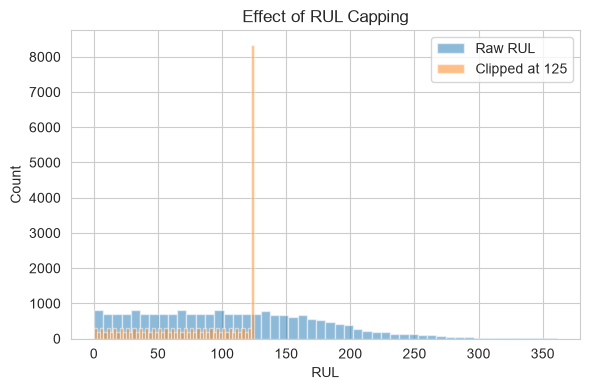

In [111]:
RUL_CAP = 125

train_fd001["RUL_clipped"] = train_fd001["RUL"].clip(upper=RUL_CAP)

plt.figure(figsize=(6, 4))
plt.hist(train_fd001["RUL"], bins=50, alpha=0.5, label="Raw RUL")
plt.hist(train_fd001["RUL_clipped"], bins=50, alpha=0.5, label=f"Clipped at {RUL_CAP}")
plt.legend()
plt.title("Effect of RUL Capping")
plt.xlabel("RUL")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 5. Train / Validation Split (by Engine)

Rows from the same engine are highly correlated across consecutive cycles. Splitting randomly by row would leak information between train and validation sets, since near-identical cycles from the same engine could land on both sides. Instead, the split is done at the **engine level**: entire engines go to either the training set or the validation set.

In [112]:
engine_ids = train_fd001["engine_id"].unique()
train_ids, val_ids = train_test_split(engine_ids, test_size=0.2, random_state=42)

train_split = train_fd001[train_fd001["engine_id"].isin(train_ids)]
val_split = train_fd001[train_fd001["engine_id"].isin(val_ids)]

X_train = train_split[feature_cols]
y_train = train_split["RUL_clipped"]

X_val = val_split[feature_cols]
y_val = val_split["RUL_clipped"]

print("Train engines:", len(train_ids), "| Train rows:", X_train.shape[0])
print("Val engines:  ", len(val_ids), "| Val rows:  ", X_val.shape[0])


Train engines: 80 | Train rows: 16561
Val engines:   20 | Val rows:   4070


## 6. Prepare the Official Test Set (Last Cycle per Engine)

For each test engine, only the final observed cycle is scored, paired with the true RUL from `RUL_FD001.txt`.

In [113]:
test_last_cycle = (
    test_fd001.sort_values(["engine_id", "cycle"])
    .groupby("engine_id")
    .tail(1)
    .reset_index(drop=True)
)

test_last_cycle = test_last_cycle.merge(rul_fd001, on="engine_id", how="left")
test_last_cycle["RUL_clipped"] = test_last_cycle["RUL"].clip(upper=RUL_CAP)

X_test = test_last_cycle[feature_cols]
y_test = test_last_cycle["RUL_clipped"]

print("Test engines:", X_test.shape[0])
test_last_cycle[["engine_id", "cycle", "RUL", "RUL_clipped"]].head()


Test engines: 100


,engine_id,cycle,RUL,RUL_clipped
0,1,31,112,112
1,2,49,98,98
2,3,126,69,69
3,4,106,82,82
4,5,98,91,91


## 7. Feature Scaling

Linear Regression benefits from standardized inputs; the scaler is fit on the training split only and applied to validation and test to avoid leakage. Tree-based models don't strictly need scaling but are run on the same scaled features for a consistent pipeline.

In [114]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## 8. Baseline Models

### 8.1 Linear Regression

In [115]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[-0.15,-0.03, 0. ,...,-1.99, 2.71, 2.6 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,86.96
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(17)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](18,)","[385.97,186.67,129.66,..., 49.34, 21.45, 0. ]"


### 8.2 Random Forest Regressor

In [116]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

### 8.3 Gradient Boosting Regressor

In [117]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
)
gb.fit(X_train_scaled, y_train)


,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

## 9. Model Evaluation and Comparison

Each model is scored on both the validation split (held-out engines from the training set) and the official FD001 test set, using RMSE, MAE, and R².

In [118]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}, preds

models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
}

results = []
test_predictions = {}

for name, model in models.items():
    val_metrics, _ = evaluate_model(model, X_val_scaled, y_val)
    test_metrics, test_preds = evaluate_model(model, X_test_scaled, y_test)
    test_predictions[name] = test_preds

    results.append({
        "Model": name,
        "Val_RMSE": val_metrics["RMSE"], "Val_MAE": val_metrics["MAE"], "Val_R2": val_metrics["R2"],
        "Test_RMSE": test_metrics["RMSE"], "Test_MAE": test_metrics["MAE"], "Test_R2": test_metrics["R2"],
    })

results_df = pd.DataFrame(results).sort_values("Test_RMSE").reset_index(drop=True)
results_df


,Model,Val_RMSE,Val_MAE,Val_R2,Test_RMSE,Test_MAE,Test_R2
0,Random Forest,17.011740,12.406223,0.833697,17.044301,11.891494,0.819096
1,Gradient Boosting,17.062516,12.541635,0.832703,17.454570,11.766629,0.810282
2,Linear Regression,20.410927,16.483550,0.760598,20.793872,16.567231,0.730747


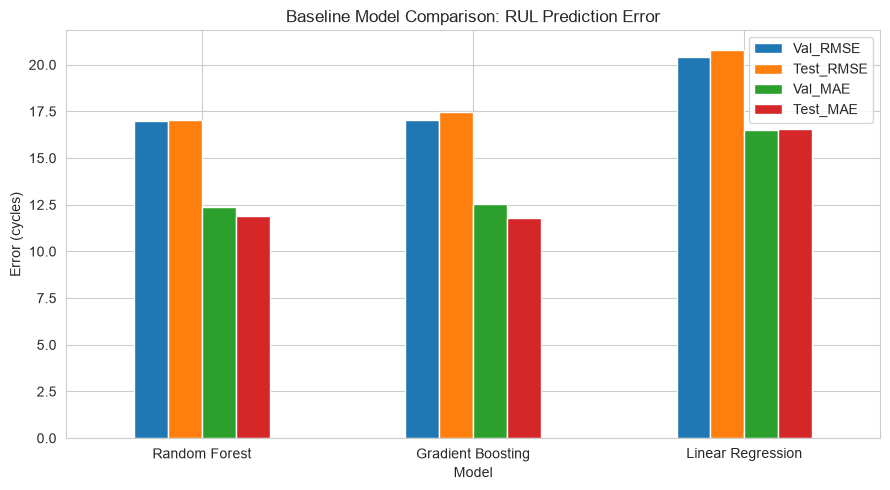

In [119]:
metrics_to_plot = ["Val_RMSE", "Test_RMSE", "Val_MAE", "Test_MAE"]

fig, ax = plt.subplots(figsize=(9, 5))
results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("Baseline Model Comparison: RUL Prediction Error")
ax.set_ylabel("Error (cycles)")
ax.set_xticklabels(results_df["Model"], rotation=0)
plt.tight_layout()
plt.show()


## 10. Feature Importance (Tree-Based Models)

Inspects which settings and sensors the Random Forest and Gradient Boosting models rely on most, and checks whether this lines up with the sensors that showed the strongest correlation with RUL in the notebook 01 EDA (`sensor11`, `sensor4`, `sensor12`, `sensor7`, `sensor15`).

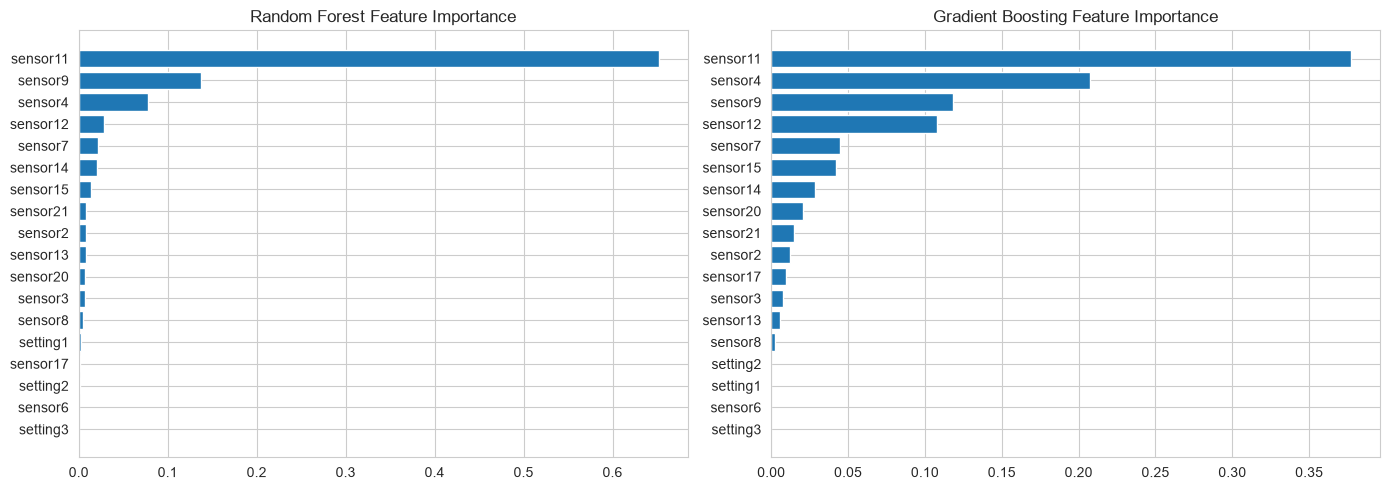

,feature,rf_importance,gb_importance
10,sensor11,0.651704,0.377214
9,sensor9,0.137257,0.118209
5,sensor4,0.077858,0.207471
11,sensor12,0.028728,0.107893
7,sensor7,0.021397,0.044461
13,sensor14,0.020279,0.028529
14,sensor15,0.013592,0.042054
17,sensor21,0.008731,0.015083
3,sensor2,0.007778,0.012011
12,sensor13,0.007685,0.005943


In [120]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "rf_importance": rf.feature_importances_,
    "gb_importance": gb.feature_importances_,
}).sort_values("rf_importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(importance_df["feature"], importance_df["rf_importance"])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest Feature Importance")

order = importance_df.sort_values("gb_importance", ascending=False)
axes[1].barh(order["feature"], order["gb_importance"])
axes[1].invert_yaxis()
axes[1].set_title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

importance_df


## 11. Predicted vs. Actual RUL on the Test Set

Visualizes how closely each model's predictions track the true RUL for the official test engines. Points near the diagonal line indicate accurate predictions.

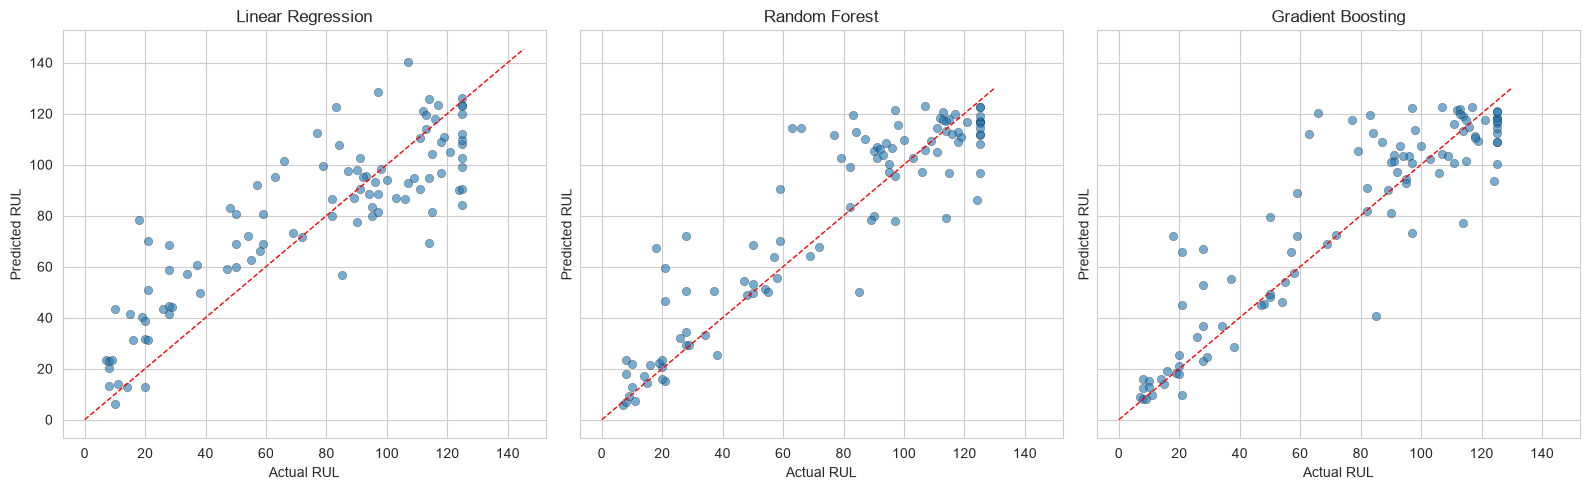

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, (name, preds) in zip(axes, test_predictions.items()):
    ax.scatter(y_test, preds, alpha=0.6, edgecolor="k", linewidth=0.3)
    lims = [0, max(y_test.max(), preds.max()) + 5]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual RUL")
    ax.set_ylabel("Predicted RUL")

plt.tight_layout()
plt.show()


## 12. Save Baseline Results and Models

Persists the comparison table and the fitted models/scaler so notebook 03 (advanced ML) can load them as a reference baseline rather than retraining from scratch.

In [122]:
os.makedirs("../reports", exist_ok=True)
os.makedirs("../models", exist_ok=True)

results_df.to_csv("../reports/baseline_model_comparison.csv", index=False)

joblib.dump(scaler, "../models/baseline_scaler.pkl")
joblib.dump(lr, "../models/baseline_linear_regression.pkl")
joblib.dump(rf, "../models/baseline_random_forest.pkl")
joblib.dump(gb, "../models/baseline_gradient_boosting.pkl")

print("Saved baseline comparison and models.")


Saved baseline comparison and models.


## Baseline Summary

This notebook established a reproducible baseline for RUL prediction on FD001 using engine-level train/validation splits, the official test set with true RUL labels, and a standard RUL-capping strategy. Three baseline regressors — Linear Regression, Random Forest, and Gradient Boosting — were trained on the same feature set and compared using RMSE, MAE, and R² on both a held-out validation split and the official test set.

These results serve as the reference point for `03_advanced_ml_modeling.ipynb`, which will explore hyperparameter tuning, XGBoost, and additional feature engineering (e.g. rolling statistics, degradation-stage indicators) to improve on this baseline. Sequential modeling with LSTM/GRU architectures, which can learn temporal degradation patterns directly from cycle sequences rather than single-cycle snapshots, is covered separately in `04_deep_learning_rul_prediction.ipynb`.